In [2]:
import os 
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.special import comb
from math import factorial

In [3]:
def find_combinations(N, IJ):
    """
    Finds all combinations of IJ numbers that sum to N
    Parameters:
    N (int): The target sum
    IJ (int): The number of variables
    Returns:
    numpy.ndarray: An array of all combinations (shape: (n_combinations, IJ))
    """
    combinations = []
    find_comb(N, IJ, [], combinations)
    return np.array(combinations)

def find_comb(remaining, num_vars, current_combination, combinations):
    """
    Recursive helper function to find combinations
    
    Parameters:
    remaining (int): Remaining sum to allocate
    num_vars (int): Number of variables left to assign
    current_combination (list): Current combination being built
    combinations (list): List to store completed combinations
    """
    if num_vars == 1:
        current_combination.append(remaining)
        combinations.append(current_combination.copy())
        current_combination.pop()  # Backtrack
        return
    
    for i in range(remaining + 1):
        current_combination.append(i)
        find_comb(remaining - i, num_vars - 1, current_combination, combinations)
        current_combination.pop()  # Backtrack    

def q_combination(z_com, N, q, I, J):
    """
    Calculate the q combinations for each z combination
    
    Parameters:
    z_com (numpy.ndarray): Array of combinations (shape: (n_combinations, I*J))
    N (int): Total number of clients
    q (numpy.ndarray): Probability matrix (shape: (I, J))
    I (int): Number of groups in first dimension
    J (int): Number of groups in second dimension
    
    Returns:
    numpy.ndarray: Array of q combinations (shape: (n_combinations, 1))
    """
    num_combinations = z_com.shape[0]
    q_com = np.zeros((num_combinations, 1))
    
    for k in range(num_combinations):
        current_z_com = z_com[k, :]
        Q_n = factorial(N)
        Q_d = 1
        l = 0  # Python uses 0-based indexing
        
        for i in range(I):
            for j in range(J):
                Q_n *= q[i, j] ** current_z_com[l]
                Q_d *= factorial(current_z_com[l])
                l += 1
                
        q_com[k, 0] = Q_n / Q_d
    
    return q_com

def pow_p(x, p):
    return x**p


# Figure 3

In [42]:
# cost_number 
I = 2
J = 2
IJ = I * J
alpha = np.array([40, 1])
theta = np.array([1, 2])
beta = np.array([0.2, 0.5])
G = 3
low_N = 4
high_N = 20
point = high_N - low_N + 1

np.random.seed(0)
random_numbers = np.random.rand(2, 2)
q = random_numbers / np.sum(random_numbers)

i = 0
c_sg_l1 = np.zeros(point)
c_sg_l2 = np.zeros(point)
c_sg = np.zeros(point)
c_si = np.zeros(point)
c_uniform = np.zeros(point)
# c_ufl_test = np.zeros(point)

for N in np.linspace(low_N, high_N, point, dtype=int):
    z_num_com = comb(N + IJ - 1, IJ - 1, exact=True)
    z_com = find_combinations(N, IJ)
    q_com = q_combination(z_com, N, q, I, J)
    rmax = 2
    
    # Stackelberg game - l1
    r_sg_l1 = cp.Variable()
    total_c_sg_l1 = 0
    gamma = np.zeros(z_num_com)
    for k in range(z_num_com):
        if np.sum(z_com[k, 0:2]) == 0:
            new_c_sg_l1 = q_com[k] * 50  # big constant
            total_c_sg_l1 += new_c_sg_l1
        else:
            gamma[k] = ((1 + beta[0])**2 * z_com[k, 0] + (1 + beta[1])**2 * z_com[k, 1]) / np.sum(z_com[k, 0:2])
            e_sg_l1 = alpha[0] * pow_p(G - gamma[k], -1) * pow_p(np.sum(z_com[k, 0:2]) * r_sg_l1, -1/2)
            p_sg_l1 = alpha[1] * np.sum(z_com[k, 0:2]) * theta[0] * r_sg_l1
            new_c_sg_l1 = q_com[k] * (e_sg_l1 + p_sg_l1)
            total_c_sg_l1 = total_c_sg_l1+ new_c_sg_l1

    problem = cp.Problem(cp.Minimize(total_c_sg_l1),
                            [r_sg_l1 >= 0])
    problem.solve()
    c_sg_l1_i = problem.value
    

    # Stackelberg game - l2
    r_sg_l2 = cp.Variable()
    total_c_sg_l2 = 0
    for k in range(z_num_com):
        gamma[k] = ((1 + beta[0])**2 * (z_com[k, 0] + z_com[k, 2]) + (1 + beta[1])**2 * (z_com[k, 1] + z_com[k, 3])) / np.sum(z_com[k, :])
        e_sg_l2 = alpha[0] * pow_p(G - gamma[k], -1) * pow_p(np.sum(z_com[k, :]) * r_sg_l2, -1/2)
        p_sg_l2 = alpha[1] * (np.sum(z_com[k, 0:2]) * theta[0] + np.sum(z_com[k, 2:4]) * theta[1]) * r_sg_l2
        new_c_sg_l2 = q_com[k] * (e_sg_l2 + p_sg_l2)
        total_c_sg_l2 += new_c_sg_l2

    problem = cp.Problem(cp.Minimize(total_c_sg_l2),
                            [r_sg_l2 >= 0])
    problem.solve()
    c_sg_l2_i = problem.value
   
    c_sg_l1[i] = c_sg_l1_i
    c_sg_l2[i] = c_sg_l2_i
    c_sg[i] = min( c_sg_l1[i], c_sg_l2[i])
    
    # AFL in strongly incomplete
    r11 = cp.Variable()
    r12 = cp.Variable()
    r21 = cp.Variable()
    r22 = cp.Variable()
    
    total_c_sg_l1 = 0
    for k in range(z_num_com):
        gamma[k] = (z_com[k, 0]*(1+beta[0])**2 + z_com[k, 1]*(1+beta[1])**2 + 
                   z_com[k, 2]*(1+beta[0])**2 + z_com[k, 3]*(1+beta[1])**2) / np.sum(z_com[k, :])
        e_r = alpha[0] * pow_p(G - gamma[k], -1) * pow_p(z_com[k, 0]*r11 + z_com[k, 1]*r12 + 
                                                        z_com[k, 2]*r21 + z_com[k, 3]*r22, -1/2)
        p1 = alpha[1] * (z_com[k, 0]*theta[0]*r11 + z_com[k, 1]*theta[0]*r12 + 
                         z_com[k, 2]*theta[1]*r21 + z_com[k, 3]*theta[1]*r22)
        p2 = alpha[1] * (theta[1] - theta[0]) * (z_com[k, 0]*r21 + z_com[k, 1]*r22)
        new_c_sg_l1 = q_com[k] * (e_r + p1 + p2)
        total_c_sg_l1 += new_c_sg_l1
    
    problem = cp.Problem(cp.Minimize(total_c_sg_l1),
                         [r11 >= 0, r12 >= 0, r21 >= 0, r22 >= 0])
    problem.solve()
    c_si[i] = problem.value
    
    # Uniform FL and strongly incomplete
    r = cp.Variable()
    total_c_uniform = 0
    for k in range(z_num_com):
        gamma[k] = (z_com[k, 0]*(1+beta[0])**2 + z_com[k, 1]*(1+beta[1])**2 + 
                    z_com[k, 2]*(1+beta[0])**2 + z_com[k, 3]*(1+beta[1])**2) / N
        e_r = alpha[0] * pow_p(G - gamma[k], -1) * pow_p(z_com[k, 0]*r + z_com[k, 1]*r + 
                                                         z_com[k, 2]*r + z_com[k, 3]*r, -1/2)
        p = alpha[1] * (z_com[k, 0]*theta[1]*r + z_com[k, 1]*theta[1]*r + 
                        z_com[k, 2]*theta[1]*r + z_com[k, 3]*theta[1]*r)
        new_c_uniform = q_com[k] * (e_r + p)
        total_c_uniform += new_c_uniform
    
    problem = cp.Problem(cp.Minimize(total_c_uniform), [r >= 0])
    problem.solve()
    c_uniform[i] = problem.value
    
    # e_ufl = 0
    # p_ufl = 0
    # for k in range(z_num_com):
    #     e_ufl += q_com[k] * (alpha[0] * pow_p(G - gamma[k], -1) * 
    #                          pow_p(z_com[k, 0]*r.value + z_com[k, 1]*r.value + 
    #                                z_com[k, 2]*r.value + z_com[k, 3]*r.value, -1/2))
    #     p_ufl += q_com[k] * alpha[1] * (z_com[k, 0]*theta[1]*r.value + z_com[k, 1]*theta[1]*r.value + 
    #                                     z_com[k, 2]*theta[1]*r.value + z_com[k, 3]*theta[1]*r.value)
    
    # c_ufl_test[i] = e_ufl + p_ufl
    i += 1

# c_com_value = 3 * (alpha[0]**2 * alpha[1] * theta[0] / (4 * (G - (1 + beta[0])**2)**2))**(1/3)
# c_com = c_com_value * np.ones(point)


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:158: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn("Objective contains too many subexpressions. "


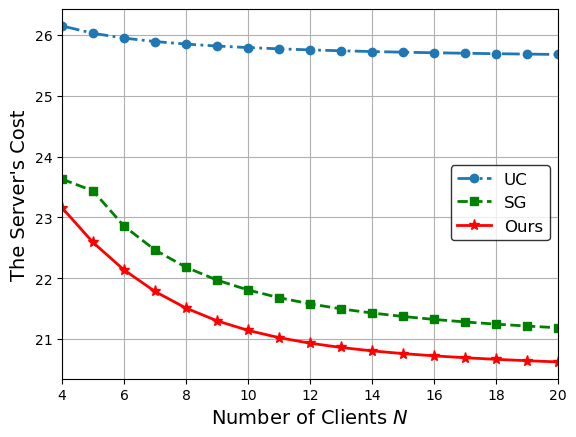

In [43]:
x = np.linspace(low_N, high_N, point)
plt.figure()
plt.plot(x, c_uniform, '-.o', linewidth=2, label='UC', markersize=6)
plt.plot(x, c_sg, '--s', linewidth=2, label='SG',color = 'green', markersize=6)
plt.plot(x, c_si, '*-', linewidth=2, label='Ours', color = 'red', markersize=8)

plt.xlim([low_N, high_N])
plt.xlabel('Number of Clients $N$', fontsize=14)
plt.ylabel("The Server's Cost", fontsize=14)
plt.grid(True)
plt.legend(
    frameon=True,           # 显示边框
    edgecolor='black',      # 边框颜色
    loc='upper right',      # 固定在右上角
    bbox_to_anchor=(1, 0.6),   # 微调位置（可选）
    fontsize = 12
)
plt.savefig('simu_result/ChangeN.pdf')
plt.show()



# Figure 5

/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:158: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn("Objective contains too many subexpressions. "


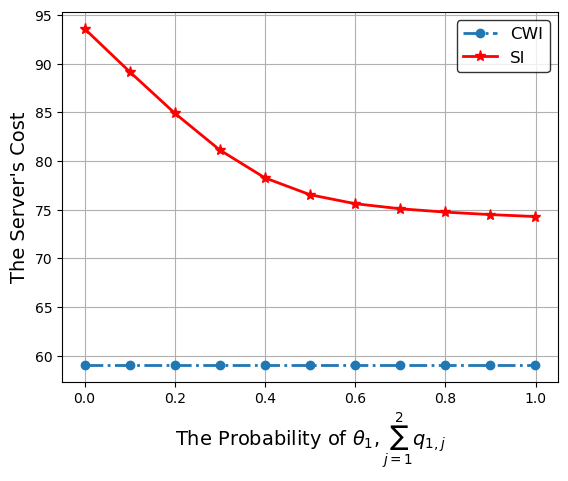

In [5]:
# cost_theta1
# Main code
I = 2
J = 2
IJ = I * J
alpha = np.array([200, 5])
theta = np.array([1, 2])
beta = np.array([0.2, 0.7])
G = 4
N = 12

# Calculate combinations
z_num_com = comb(N + IJ - 1, IJ - 1, exact=True)
z_com = find_combinations(N, IJ)

# Make theta as the x-axis
q_beta = np.array([1/2, 1/2])
c_si_2 = np.zeros(11)
q_theta1_values = np.linspace(0.0001, 0.9999, 11)

for i, q_theta1 in enumerate(q_theta1_values):
    q_theta2 = 1 - q_theta1
    q1 = np.array([
        [q_theta1 * q_beta[0], q_theta1 * q_beta[1]],
        [q_theta2 * q_beta[0], q_theta2 * q_beta[1]]
    ])
    
    q_com = q_combination(z_com, N, q1, I, J)
    
    # CVXPY optimization
    r11 = cp.Variable()
    r12 = cp.Variable()
    r21 = cp.Variable()
    r22 = cp.Variable()
    
    total_c = 0
    gamma = np.zeros(z_num_com)
    
    for k in range(z_num_com):
        gamma[k] = (z_com[k,0]*(1+beta[0])**2 + z_com[k,1]*(1+beta[1])**2 + 
                    z_com[k,2]*(1+beta[0])**2 + z_com[k,3]*(1+beta[1])**2) / N
        e_r = alpha[0] * pow_p(G - gamma[k], -1) * pow_p(
            z_com[k,0]*r11 + z_com[k,1]*r12 + z_com[k,2]*r21 + z_com[k,3]*r22, -1/2)
        p1 = alpha[1] * (z_com[k,0]*theta[0]*r11 + z_com[k,1]*theta[0]*r12 + 
                         z_com[k,2]*theta[1]*r21 + z_com[k,3]*theta[1]*r22)
        p2 = alpha[1] * (theta[1] - theta[0]) * (z_com[k,0]*r21 + z_com[k,1]*r22)
        new_c = q_com[k,0] * (e_r + p1 + p2)
        total_c += new_c
    
    problem = cp.Problem(cp.Minimize(total_c),
                         [r11 >= 0, r12 >= 0, r21 >= 0, r22 >= 0])
    problem.solve()
    c_si_2[i] = problem.value

# Calculate constant value
c_com_value = 3 * (alpha[0]**2 * alpha[1] * theta[0] / (4 * (G - (1 + beta[0])**2)**2))**(1/3)
c_com = c_com_value * np.ones(11)

# Plotting
x = np.linspace(0.0001, 0.9999, 11)
plt.figure()
plt.plot(x, c_com, '-.o', linewidth=2, label='CWI', markersize =6)
plt.plot(x, c_si_2, '-*', linewidth=2, label='SI', color = 'red', markersize = 8)

plt.xlabel('The Probability of $\\theta_1, \\sum_{j=1}^2 q_{1,j}$', fontsize=14)
plt.ylabel("The Server's Cost", fontsize=14)
plt.legend(
    frameon=True,           # 显示边框
    edgecolor='black',      # 边框颜色
    loc='upper right',      # 固定在右上角
    # bbox_to_anchor=(1, 0.4),   # 微调位置（可选）
    fontsize = 12
)
plt.grid(True)
plt.savefig('simu_result/cost_theta1_20250825.pdf',bbox_inches='tight')
plt.show()
